# Transformer 번역기 (한국어 → 영어)


## 전체 구조 한눈에 보기

```
[원문 데이터]  ──▶ 정제/전처리 ──▶ SentencePiece 토큰화 ──▶ 텐서 패딩
                                                              │
                                                              ▼
                                            ┌───────── Transformer ─────────┐
                                            │  Embedding + Positional Enc.  │
                                            │            │                  │
                                            │     ┌──────┴──────┐          │
                                            │     ▼             ▼          │
                                            │  Encoder ──▶  Decoder ──▶ FC │
                                            └───────────────────────────────┘
                                                              │
                                                              ▼
                                                       [영어 토큰 예측]
```

### 단계 요약
1. **데이터 준비**: 한·영 병렬 코퍼스 다운로드 → 중복 제거 → 텍스트 정규화
2. **토큰화**: SentencePiece로 한국어/영어 각각 vocab 학습 → 토큰 ID로 변환
3. **모델**: Multi-Head Attention 기반 Encoder-Decoder 트랜스포머
4. **학습**: Noam 스케줄러 + Label Smoothing CrossEntropy
5. **추론**: Greedy decoding으로 번역

## 0. 환경 설정
- 필요한 라이브러리 임포트 + 재현성을 위한 seed 고정 + GPU 사용 여부 확인

In [1]:
# ─────────────────────────────────────────────────────────────
# 표준 라이브러리
# ─────────────────────────────────────────────────────────────
import os      # 파일 경로/디렉토리 처리
import re      # 정규표현식 (텍스트 전처리)
import time    # 학습 시간 측정
import random  # 미니배치 셔플
import math    # sqrt 등 수학 함수

# ─────────────────────────────────────────────────────────────
# 수치/딥러닝 라이브러리
# ─────────────────────────────────────────────────────────────
import numpy as np                              # Positional Encoding 계산용
import torch                                    # 텐서 + 자동미분
import torch.nn as nn                           # 신경망 모듈 (Linear, Embedding 등)
import torch.nn.functional as F                 # softmax, log_softmax 등 함수형 API
import torch.optim as optim                     # Adam 등 옵티마이저
from torch.nn.utils.rnn import pad_sequence     # 가변 길이 시퀀스 패딩 헬퍼
import sentencepiece as spm                     # 서브워드 토크나이저
from tqdm.notebook import tqdm                  # 진행률 표시 (주피터용)

# ─────────────────────────────────────────────────────────────
# 재현성(reproducibility)을 위해 모든 난수 seed를 같은 값으로 고정
# - 같은 seed → 같은 weight 초기화 → 같은 학습 결과
# - 디버깅/실험 비교할 때 필수
# ─────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)            # 파이썬 내장 random 모듈
np.random.seed(SEED)         # numpy 난수
torch.manual_seed(SEED)      # CPU 쪽 torch 난수
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # GPU 쪽 torch 난수 (모든 GPU)

# GPU가 있으면 'cuda', 없으면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


- 한글 폰트 설치

In [27]:
# 1) 나눔 폰트 설치
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

# 2) matplotlib 캐시 삭제
import shutil, matplotlib
shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)

# 3) 폰트 등록 + 적용
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('한글 폰트 적용 완료')

한글 폰트 적용 완료


## 1. 데이터 다운로드
- 한·영 병렬 뉴스 코퍼스를 받아 `./data/` 폴더에 푼다.  
- 환경별로 경로가 달라서 Colab / Kaggle / 로컬을 자동으로 구분함.

In [2]:
# ─────────────────────────────────────────────────────────────
# 작업 디렉토리 결정 (환경별로 다름)
#   - Colab : Google Drive 마운트 후 그 안에 폴더 만들기
#   - Kaggle: /kaggle/working/ 이 유일하게 쓰기 가능한 곳
#   - 로컬  : 현재 폴더 그대로
# ─────────────────────────────────────────────────────────────
if os.path.exists('/kaggle/working'):
    # 캐글 환경 감지
    os.chdir('/kaggle/working')
else:
    try:
        # Colab 환경 감지 (google.colab 임포트가 되면 Colab)
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
        PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/transformer_clean'
        os.makedirs(PROJECT_DIR, exist_ok=True)
        os.chdir(PROJECT_DIR)
    except ImportError:
        # 로컬 환경 — 현재 디렉토리 그대로
        pass

# 데이터를 저장할 하위 폴더 만들기 (이미 있어도 에러 안 남)
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

# 한·영 병렬 코퍼스 (뉴스 도메인) - github에 공개되어 있음
URL = 'https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz'
kor_path = f'{DATA_DIR}/korean-english-park.train.ko'  # 최종 한국어 파일 경로
eng_path = f'{DATA_DIR}/korean-english-park.train.en'  # 최종 영어 파일 경로

# 한국어 파일이 아직 없으면(=처음 실행이면) 다운로드 + 압축 해제
if not os.path.exists(kor_path):
    print('다운로드 중...')
    os.system(f'wget -q {URL} -P {DATA_DIR}')                                  # 1) tar.gz 받기
    os.system(f'tar -xzf {DATA_DIR}/korean-english-park.train.tar.gz -C {DATA_DIR}')  # 2) 압축 풀기

print('데이터 준비 완료:', os.listdir(DATA_DIR))

다운로드 중...
데이터 준비 완료: ['korean-english-park.train.tar.gz', 'korean-english-park.train.ko', 'korean-english-park.train.en']


## 2. 데이터 정제 + 전처리

**함수 설명**
- `clean_corpus(ko, en)`: 두 파일을 같은 줄끼리 묶어 set으로 중복 제거. 같은 문장 쌍이 학습 데이터에 여러 번 들어가는 걸 막음.
- `preprocess_sentence(s)`: 소문자화 → 알파벳/한글/문장부호 외 제거 → 문장부호 띄어쓰기 → 공백 정리. 토크나이저가 깨끗한 입력을 받도록 정규화.

In [3]:
def clean_corpus(kor_path, eng_path):
    """
    한·영 파일을 읽어 (kor\teng) 쌍으로 합친 뒤 중복 제거한 리스트 반환.
    
    중복 제거 이유
      - 뉴스 코퍼스에는 같은 문장이 반복되는 경우가 많음
      - 중복을 두면 학습이 그 문장에 편향됨
    """
    # 한국어 파일 읽고 줄 단위로 쪼개기
    with open(kor_path, 'r', encoding='utf-8') as f:
        kor = f.read().splitlines()
    # 영어 파일도 동일하게
    with open(eng_path, 'r', encoding='utf-8') as f:
        eng = f.read().splitlines()

    # 한국어와 영어 줄 수가 다르면 병렬 코퍼스가 깨진 것 → 즉시 에러
    assert len(kor) == len(eng), '한·영 줄 수가 다르면 병렬 코퍼스가 깨진 것'

    # 한 문장 쌍을 "한국어\t영어" 형태로 합친 뒤,
    # set()으로 감싸 중복을 한 번에 제거하고, 다시 list로 변환
    return list(set(f'{k}\t{e}' for k, e in zip(kor, eng)))


def preprocess_sentence(sentence):
    """
    문장을 모델 친화적으로 정규화.
    
    4단계:
      1) 소문자화        : 'Hello' == 'hello'로 처리하기 위해
      2) 불필요 문자 제거 : 숫자/이모지/특수기호 같은 학습에 방해되는 것 제거
      3) 문장부호 분리   : 'Hello!' → 'hello !' 형태로 (토크나이저가 별도 토큰으로 인식)
      4) 공백 정리      : 연속 공백 → 하나로
    """
    # 1) 모든 영문자를 소문자로 (한글은 영향 없음)
    sentence = sentence.lower()

    # 2) 영문자(a-zA-Z), 한글(가-힣), 문장부호(? . ! ,) 외의 모든 문자를 공백으로 치환
    #    [^...] : ... 가 아닌 모든 것을 매칭
    sentence = re.sub(r'[^a-zA-Z가-힣?.!,]+', ' ', sentence)

    # 3) 문장부호 양옆에 공백 추가 → 토큰으로 분리되도록
    #    \1 은 매칭된 첫 그룹(문장부호 자체)을 그대로 다시 넣는다는 뜻
    sentence = re.sub(r'([?.!,])', r' \1 ', sentence)

    # 4) 한 개 이상의 공백을 단일 공백으로 압축하고, 양 끝 공백 제거
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    return sentence


# ─────────────────────────────────────────────────────────────
# 실제 실행: 정제 → 전처리
# ─────────────────────────────────────────────────────────────
cleaned = clean_corpus(kor_path, eng_path)  # 중복 제거된 (ko\ten) 쌍 리스트

kor_corpus = []  # 전처리된 한국어 문장만 모음
eng_corpus = []  # 전처리된 영어 문장만 모음

for pair in cleaned:
    k, e = pair.split('\t')                    # 탭으로 한·영 분리
    kor_corpus.append(preprocess_sentence(k))  # 한국어 전처리 후 저장
    eng_corpus.append(preprocess_sentence(e))  # 영어 전처리 후 저장

# 결과 확인
print(f'문장 쌍: {len(kor_corpus):,}개')
print('예시 KO:', kor_corpus[0][:80])
print('예시 EN:', eng_corpus[0][:80])

문장 쌍: 78,968개
예시 KO: cnn 네팔 통신원 만네쉬 쉬렐사는 카투만두에서 구조대는 아직 포기하지 않았다 며 아직 현장에서 수색작업을 하고 있다 고 전했다 .
예시 EN: they re still there , and they re still looking for bodies , journalist manesh s


## 3. SentencePiece 토큰화

**왜 SentencePiece?**
- 단어(word) 단위로 토큰화하면 OOV(미등록 단어)가 너무 많이 생김
- 문자(char) 단위로 하면 시퀀스가 너무 길어짐
- 그 중간인 **서브워드(subword)** 단위로 쪼개면 균형이 좋음 → SentencePiece가 자동으로 학습

**특수 토큰 약속** (모든 모델에서 공통)
- `PAD=0` : 길이 맞추기용 패딩
- `BOS=1` : 문장 시작 (Begin Of Sentence)
- `EOS=2` : 문장 끝 (End Of Sentence)
- `UNK=3` : vocab에 없는 단어 (Unknown)

**함수**: `train_spm(corpus, lang, vocab_size)` → 코퍼스로 SentencePiece 모델 학습하고 로드된 토크나이저 반환.

In [4]:
# 특수 토큰 ID 약속 — 모델/토크나이저 전체에서 동일하게 사용
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3

# 한국어/영어 vocab 크기 (둘 다 8,000개로 통일)
# 너무 작으면 OOV 많아짐, 너무 크면 임베딩 파라미터가 폭증
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 8000


def train_spm(corpus, lang, vocab_size, save_dir='./data'):
    """
    corpus 리스트로 SentencePiece 모델을 학습하고 로드된 토크나이저를 반환.
    
    절차:
      1) corpus(list of str)를 임시 텍스트 파일로 저장 (SP는 파일 입력만 받음)
      2) SentencePieceTrainer로 학습 → .model, .vocab 두 파일 생성
      3) 학습된 .model을 다시 로드해 사용 가능한 토크나이저 객체로 반환
    """
    # 1) 코퍼스를 임시 파일로 저장
    txt_path = f'{save_dir}/{lang}_corpus.txt'      # 예: ./data/ko_corpus.txt
    model_prefix = f'{save_dir}/{lang}_spm'         # 예: ./data/ko_spm  (.model/.vocab가 prefix에 붙음)
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(corpus))                  # 한 줄에 한 문장씩

    # 2) SentencePiece 학습
    #    --input         : 학습용 텍스트 파일
    #    --model_prefix  : 생성될 파일 prefix (ko_spm.model / ko_spm.vocab)
    #    --vocab_size    : 사전 크기
    #    --pad_id 등     : 특수 토큰의 ID를 위에서 약속한 값으로 고정
    spm.SentencePieceTrainer.train(
        f'--input={txt_path} --model_prefix={model_prefix} '
        f'--vocab_size={vocab_size} '
        f'--pad_id={PAD_ID} --bos_id={BOS_ID} --eos_id={EOS_ID} --unk_id={UNK_ID}'
    )

    # 3) 학습된 모델 로드 후 반환
    sp = spm.SentencePieceProcessor()
    sp.Load(f'{model_prefix}.model')
    return sp


# 한국어/영어 각각 토크나이저 학습 (몇 분 걸림)
kor_tokenizer = train_spm(kor_corpus, 'ko', SRC_VOCAB_SIZE)
eng_tokenizer = train_spm(eng_corpus, 'en', TGT_VOCAB_SIZE)

# 디코더가 학습할 때 정답에 시작/끝 토큰이 자동으로 붙어야 하므로
#   영어 토크나이저에만 "bos:eos" 옵션을 설정함
#   예: 'hello' → [BOS, 'hello', EOS]
eng_tokenizer.set_encode_extra_options('bos:eos')

# 학습된 토크나이저 미리보기 (어떤 토큰이 자주 등장하는지 확인용)
print('한국어 vocab 샘플:', [kor_tokenizer.id_to_piece(i) for i in range(10)])
print('영어   vocab 샘플:', [eng_tokenizer.id_to_piece(i) for i in range(10)])

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./data/ko_corpus.txt --model_prefix=./data/ko_spm --vocab_size=8000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./data/ko_corpus.txt
  input_format: 
  model_prefix: ./data/ko_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_

한국어 vocab 샘플: ['<pad>', '<s>', '</s>', '<unk>', '▁.', '▁', '을', '의', '는', '은']
영어   vocab 샘플: ['<pad>', '<s>', '</s>', '<unk>', '▁the', '▁.', '▁,', 's', 'ed', '▁a']


acy: 0
  differential_privacy_noise_level: 0
  differential_privacy_clipping_threshold: 0
}
normalizer_spec {
  name: nmt_nfkc
  add_dummy_prefix: 1
  remove_extra_whitespaces: 1
  escape_whitespaces: 1
  normalization_rule_tsv: 
}
denormalizer_spec {}
trainer_interface.cc(355) LOG(INFO) SentenceIterator is not specified. Using MultiFileSentenceIterator.
trainer_interface.cc(186) LOG(INFO) Loading corpus: ./data/en_corpus.txt
trainer_interface.cc(411) LOG(INFO) Loaded all 78956 sentences
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <pad>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <s>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: </s>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <unk>
trainer_interface.cc(432) LOG(INFO) Normalizing sentences...
trainer_interface.cc(541) LOG(INFO) all chars count=10661485
trainer_interface.cc(552) LOG(INFO) Done: 99.9909% characters are covered.
trainer_interface.cc(562) LOG(INFO) Alphabet size=29
trainer_interfac

## 4. 학습 데이터 만들기 (길이 필터 + 텐서화)
- 토큰 50개 초과 문장은 제외 (학습 속도/메모리 절약)
- 각 문장을 LongTensor로 저장 (나중에 배치 만들 때 패딩만 하면 됨)

In [5]:
# 최대 시퀀스 길이 — 이보다 긴 문장은 학습에서 제외
# 너무 길면 self-attention의 O(N^2) 계산이 폭증하므로 적당히 잘라야 함
MAX_LEN = 50

src_corpus = []  # 한국어 토큰 ID 텐서들의 리스트 (source)
tgt_corpus = []  # 영어 토큰 ID 텐서들의 리스트 (target)

# 한·영 쌍을 묶어 한 번에 순회 (tqdm으로 진행률 표시)
for k, e in tqdm(list(zip(kor_corpus, eng_corpus))):
    # 텍스트를 토큰 ID 리스트로 변환
    # 예: "안녕하세요" → [4, 521, 89]
    s = kor_tokenizer.encode_as_ids(k)
    # 영어는 set_encode_extra_options 덕분에 [BOS, ..., EOS] 형태로 자동 변환됨
    t = eng_tokenizer.encode_as_ids(e)

    # 양쪽 모두 MAX_LEN 이하인 쌍만 학습 데이터로 채택
    if len(s) <= MAX_LEN and len(t) <= MAX_LEN:
        # 파이썬 리스트 → PyTorch LongTensor 변환 (토큰 ID는 정수)
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f'학습용 문장 쌍: {len(src_corpus):,}')

  0%|          | 0/78968 [00:00<?, ?it/s]

학습용 문장 쌍: 69,223


## 5. Transformer 모델 설계

구성요소(아래로 갈수록 큰 단위):
1. `positional_encoding` — 위치 정보를 sin/cos로 인코딩 (어텐션은 순서를 모르니까 따로 더해줌)
2. `MultiHeadAttention` — Q·K·V로 어텐션 계산 + 여러 헤드로 병렬
3. `PoswiseFeedForward` — 각 토큰을 독립적으로 비선형함
4. `EncoderLayer` / `DecoderLayer` — 위 모듈을 잔차연결 + LayerNorm으로 묶은 한 층
5. `Transformer` — 임베딩 + 인코더 N층 + 디코더 N층 + 출력 FC를 합친 최종 모델

### 5-1. Positional Encoding
$PE_{(pos,2i)}=\sin(pos/10000^{2i/d})$, $PE_{(pos,2i+1)}=\cos(\cdot)$

- **어텐션은 순서 정보를 모름** (행렬 곱은 순서가 바뀌어도 결과 동일) → 위치를 직접 임베딩에 더해야 함
- sin/cos를 쓰면 위치 간 상대거리를 모델이 학습하기 쉬워짐

In [7]:
def positional_encoding(max_len, d_model):
    """
    (max_len, d_model) 크기의 위치 인코딩 텐서 생성.
    
    Args:
      max_len : 가장 긴 시퀀스 길이 (이만큼 위치 벡터 미리 계산)
      d_model : 임베딩 차원 수 (=위치 벡터 차원과 동일)
    Returns:
      (max_len, d_model) 모양의 float32 텐서
    """
    # pos:  [[0], [1], [2], ..., [max_len-1]]   shape: (max_len, 1)
    pos = np.arange(max_len)[:, None]
    # i:    [[0, 1, 2, ..., d_model-1]]         shape: (1, d_model)
    i = np.arange(d_model)[None, :]

    # 분모: 10000^(2*(i//2)/d_model)
    #   - i//2 로 짝수/홀수가 같은 분모를 갖도록 만듦 (sin/cos가 쌍을 이루도록)
    # angle shape: (max_len, d_model)
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)

    # 짝수 차원(0, 2, 4, ...)에는 sin
    angle[:, 0::2] = np.sin(angle[:, 0::2])
    # 홀수 차원(1, 3, 5, ...)에는 cos
    angle[:, 1::2] = np.cos(angle[:, 1::2])

    return torch.tensor(angle, dtype=torch.float32)

### 5-2. Multi-Head Attention
- Query가 Key 중 어느 쪽을 얼마나 볼지 계산해서 Value를 가중합.

```
Attention(Q, K, V) = softmax(QK^T / √d_k) · V
```

- **멀티헤드** 한 번의 어텐션은 한 가지 관점만 학습. 여러 헤드를 두면 각각 다른 패턴(문법/의미/위치 등)을 동시에 학습 가능.

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        # d_model을 num_heads로 정확히 나눠떨어져야 헤드별 depth가 정수가 됨
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads   # 헤드 하나가 담당하는 차원 수

        # Q, K, V로 변환하는 학습 가능한 선형층 (각각 d_model → d_model)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        # 헤드 결합 후 한 번 더 섞어주는 출력 선형층
        self.linear = nn.Linear(d_model, d_model)
        # 추가: attention weight에 적용할 dropout (원논문 표준)
        self.attn_dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        """
        (B, T, d_model) → (B, num_heads, T, depth) 로 reshape.
        헤드를 batch처럼 다뤄 병렬로 어텐션을 계산하기 위함.
        """
        B, T, _ = x.shape
        # 마지막 차원을 (num_heads, depth)로 쪼개고
        x = x.view(B, T, self.num_heads, self.depth)
        # head 차원을 앞으로 끌어옴: (B, num_heads, T, depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        """
        (B, num_heads, T, depth) → (B, T, d_model) 로 되돌리기.
        split_heads의 역연산.
        """
        B, _, T, _ = x.shape
        # head 차원을 다시 뒤로 빼고, contiguous로 메모리 정렬 후 합치기
        return x.permute(0, 2, 1, 3).contiguous().view(B, T, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # 1) Linear projection 후 헤드별로 분할
        Q = self.split_heads(self.W_q(Q))   # (B, h, Tq, depth)
        K = self.split_heads(self.W_k(K))   # (B, h, Tk, depth)
        V = self.split_heads(self.W_v(V))   # (B, h, Tk, depth)

        # 2) Scaled Dot-Product Attention
        #    scores = Q · K^T / √depth
        #    √depth로 나누는 이유: 차원이 클수록 dot product가 커져 softmax가 포화되는 걸 방지
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)

        # 3) 마스킹: mask=1인 자리는 -∞에 가깝게 만들어 softmax 후 0이 되도록
        if mask is not None:
            scores = scores.masked_fill(mask == 1, -1e9)

        # 4) 마지막 차원(=Key 축)에 softmax → 어텐션 가중치
        attn = F.softmax(scores, dim=-1)
        # 추가: 어텐션 가중치에 dropout 적용 (과적합 방지)
        attn = self.attn_dropout(attn)

        # 5) 가중치로 Value를 가중합 → 컨텍스트 벡터
        out = torch.matmul(attn, V)         # (B, h, Tq, depth)

        # 6) 헤드 합치고 출력 선형층 통과
        out = self.combine_heads(out)       # (B, Tq, d_model)
        out = self.linear(out)              # (B, Tq, d_model)
        return out, attn

### 5-3. Position-wise Feed Forward
- 각 토큰 위치마다 똑같이 적용되는 2층 MLP: `Linear → ReLU → Linear`
- 각 토큰을 독립적으로 비선형화함.
- 어텐션이 "다른 토큰을 보는" 역할이라면, FFN은 "각 토큰의 정보를 깊게 가공하는" 역할.

In [9]:
class PoswiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        # 통상 d_ff = 4 * d_model로 잡음 (예: d_model=256 → d_ff=1024)
        self.fc1 = nn.Linear(d_model, d_ff)   # 차원 늘리기 (정보 확장)
        self.fc2 = nn.Linear(d_ff, d_model)   # 차원 줄이기 (원래대로 복원)

    def forward(self, x):
        # 확장 → 비선형(ReLU) → 축소
        return self.fc2(F.relu(self.fc1(x)))

### 5-4. Encoder / Decoder Layer
- **Encoder layer** = Self-Attention + FFN (각각 잔차연결 + LayerNorm)
- **Decoder layer** = Masked Self-Attention + Cross-Attention(인코더 출력을 봄) + FFN

- **Pre-LN 구조**: `LayerNorm → SubLayer → Dropout → +residual` 순서. 학습 안정성이 좋아 최신 구현에서 표준.

In [10]:
class EncoderLayer(nn.Module):
    """
    Pre-LN 진행방식
    인코더 한 층 = Self-Attention 블록 + FFN 블록
    각 블록은 (LayerNorm → SubLayer → Dropout → +Residual) 구조
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        # ★ v3: dropout을 명시적으로 전달 (attention dropout이 작동하도록)
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForward(d_model, d_ff)           # 위치별 MLP
        # LayerNorm을 두 블록 각각에 하나씩 (총 2개)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # ── 블록 1: Self-Attention ──
        # Pre-LN: 먼저 정규화한 뒤 어텐션에 넣음
        normed = self.norm1(x)
        h, _ = self.self_attn(normed, normed, normed, mask)   # Q=K=V=normed (self-attn)
        x = x + self.dropout(h)                                # 잔차 연결

        # ── 블록 2: FFN ──
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class DecoderLayer(nn.Module):
    """
    디코더 한 층 = Masked Self-Attn + Cross-Attn(인코더 출력 봄) + FFN
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        # ★ v3: dropout 명시 전달
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForward(d_model, d_ff)
        # 세 블록이 있으므로 LayerNorm도 3개
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_mask, cross_mask):
        # ── 블록 1: Masked Self-Attention ──
        # dec_mask로 미래 토큰을 보지 못하게 (causal masking)
        normed = self.norm1(x)
        h, _ = self.self_attn(normed, normed, normed, dec_mask)
        x = x + self.dropout(h)

        # ── 블록 2: Cross-Attention ──
        # Query=디코더 현재 상태, Key/Value=인코더 출력
        # 디코더가 한국어 입력의 어느 부분을 보고 영어 단어를 생성할지 결정
        h, _ = self.cross_attn(self.norm2(x), enc_out, enc_out, cross_mask)
        x = x + self.dropout(h)

        # ── 블록 3: FFN ──
        x = x + self.dropout(self.ffn(self.norm3(x)))
        return x

### 5-5. Transformer (전체)
- 임베딩 → 위치 인코딩 더하기 → Encoder N층 → Decoder N층 → vocab 사이즈 FC.

- **Weight tying**: 디코더 임베딩과 출력 FC가 weight를 공유 (파라미터 절약 + BLEU 향상).

In [12]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        # ── 임베딩 ──
        # 소스(한국어)와 타겟(영어)은 vocab이 다르므로 별도 임베딩 사용
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # ── 위치 인코딩 ──
        # register_buffer: 학습되지 않지만 state_dict에 포함되고 .to(device)도 자동 따라감
        self.register_buffer('pos_enc', positional_encoding(max_len, d_model))

        self.dropout = nn.Dropout(dropout)

        # ── 인코더/디코더 레이어 N개씩 쌓기 ──
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        # ── 최종 출력층 ──
        # 디코더 출력을 vocab 크기로 투영 → 각 vocab의 점수(logit)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        # Weight tying: 디코더 임베딩 weight를 그대로 재사용
        #   - 임베딩 행렬 (tgt_vocab_size, d_model)
        #   - FC      행렬 (tgt_vocab_size, d_model)  ← shape이 같음
        self.fc.weight = self.dec_emb.weight

        # ★★★ v3 핵심 수정: 초기화 ★★★
        # 이게 빠지면 초기 loss가 폭주(2499)하고 학습이 정체됨
        self._init_weights()

    def _init_weights(self):
        """
        트랜스포머에 적합한 초기화.
        
        왜 필요한가?
          - nn.Embedding 기본 초기화: N(0, 1) → std=1 (너무 큼)
          - nn.Linear   기본 초기화: uniform → std ≈ 0.01 (적절)
          - Weight tying으로 임베딩이 FC weight가 되면, FC가 std=1 weight를 사용
            → 초기 logit이 √d_model 배 폭증 → softmax 포화 → loss 폭주
        
        해결:
          1) 모든 다차원 파라미터에 Xavier uniform 적용 (입출력 차원에 맞는 스케일)
          2) 임베딩은 N(0, d_model^-0.5)로 다시 설정 — weight tying과 √d_model 스케일링이
             서로 상쇄되어 안정적인 초기 logit을 만들도록
          3) Xavier가 fc를 덮어썼을 수 있으므로 weight tying 재적용
        """
        # 1) 다차원 파라미터(weight matrix)에 Xavier uniform
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

        # 2) 임베딩만 작은 std로 재초기화
        nn.init.normal_(self.enc_emb.weight, mean=0.0, std=self.d_model ** -0.5)
        nn.init.normal_(self.dec_emb.weight, mean=0.0, std=self.d_model ** -0.5)

        # 3) weight tying 재적용 (1) 단계에서 fc가 별도 init 되었을 수 있으므로
        self.fc.weight = self.dec_emb.weight

    def _embed(self, emb_layer, x):
        """
        토큰 ID → 임베딩 + 스케일링 + 위치 인코딩 + 드롭아웃.
        인코더/디코더 입력 모두 동일한 절차이므로 함수로 분리.
        """
        T = x.shape[1]                                          # 현재 시퀀스 길이
        # 임베딩 후 √d_model 곱 (원논문 권고)
        # 임베딩 std=d_model^-0.5 × √d_model = 1 이 되어 적당한 스케일이 됨
        out = emb_layer(x) * math.sqrt(self.d_model)
        # 미리 계산해 둔 위치 인코딩의 앞 T개만 잘라서 더함
        out = out + self.pos_enc[:T].unsqueeze(0).to(x.device)
        return self.dropout(out)

    def encode(self, src, enc_mask):
        """인코더 단독 실행 (추론 시 한 번만 호출하고 재사용하기 위해 분리)."""
        h = self._embed(self.enc_emb, src)
        for layer in self.enc_layers:
            h = layer(h, enc_mask)
        return h

    def decode(self, tgt, enc_out, dec_mask, cross_mask):
        """디코더 단독 실행."""
        h = self._embed(self.dec_emb, tgt)
        for layer in self.dec_layers:
            h = layer(h, enc_out, dec_mask, cross_mask)
        return h

    def forward(self, src, tgt, enc_mask, dec_mask, cross_mask):
        """학습 시 사용: 인코더 → 디코더 → 출력 FC까지 한 번에."""
        enc_out = self.encode(src, enc_mask)
        dec_out = self.decode(tgt, enc_out, dec_mask, cross_mask)
        return self.fc(dec_out)   # (B, T, tgt_vocab_size) — 각 위치마다 vocab 점수

### 5-6. 마스크 만들기
트랜스포머 3가지 마스크:
1. **인코더 패딩 마스크** — `<pad>` 토큰을 어텐션에서 무시 (입력 길이가 제각각이라 패딩한 자리가 점수에 영향 주면 안됨)
2. **디코더 셀프 마스크** — 패딩 + **미래 토큰** 가리기 (학습 시 디코더가 정답을 미리 보면 안되므로)
3. **크로스 어텐션 마스크** — 디코더가 인코더 출력을 볼 때, 인코더 쪽의 `<pad>`만 가림

In [13]:
def padding_mask(seq):
    """
    seq에서 PAD(0)인 위치를 1, 나머지를 0으로 만든 마스크.
    
    어텐션 점수 행렬과 브로드캐스팅하기 좋게 (B, 1, 1, T) 모양으로 확장.
      B: 배치, T: 시퀀스 길이
    """
    return (seq == PAD_ID).float()[:, None, None, :]


def causal_mask(size):
    """
    미래 시점을 가리는 상삼각 마스크 (size, size).
    
    예시 (size=4):
        [[0,1,1,1],     ← 0번 위치는 0번까지만 봄
         [0,0,1,1],     ← 1번 위치는 0~1번까지만 봄
         [0,0,0,1],     ← 2번 위치는 0~2번까지만 봄
         [0,0,0,0]]     ← 3번 위치는 모두 볼 수 있음
    
    diagonal=1: 대각선 위쪽만 1로 채움 (자기 자신은 볼 수 있음)
    """
    return torch.triu(torch.ones(size, size), diagonal=1)


def make_masks(src, tgt):
    """학습/추론에 필요한 3가지 마스크를 한 번에 생성."""
    # 1) 인코더용: 한국어 입력에서 PAD만 가리기
    enc_mask = padding_mask(src)

    # 2) 크로스용: 디코더가 인코더를 볼 때 → 인코더 쪽 PAD만 가리면 됨
    #    (인코더 마스크를 그대로 재사용)
    cross_mask = enc_mask

    # 3) 디코더 셀프용: 패딩 + 미래 토큰 둘 다 가려야 함
    dec_pad = padding_mask(tgt)                              # (B,1,1,Tt) — 영어 쪽 PAD
    dec_cau = causal_mask(tgt.shape[1]).to(tgt.device)       # (Tt,Tt)    — 미래 가리기
    # 둘 중 하나라도 1이면 가려야 하므로 max 연산
    dec_mask = torch.max(dec_pad, dec_cau)

    return enc_mask, dec_mask, cross_mask

## 6. 하이퍼파라미터 + 모델 인스턴스화

In [14]:
# ─────────────────────────────────────────────────────────────
# 모델 구조 관련 하이퍼파라미터
# ─────────────────────────────────────────────────────────────
N_LAYERS = 4      # 인코더/디코더를 몇 층 쌓을지 (원논문은 6)
D_MODEL  = 256    # 임베딩/은닉 차원 (원논문은 512)
N_HEADS  = 8      # 멀티헤드 어텐션의 헤드 수 (D_MODEL % N_HEADS == 0)
D_FF     = 1024   # FFN 중간 차원 (보통 D_MODEL * 4)
DROPOUT  = 0.1    # 드롭아웃 비율
POS_LEN  = MAX_LEN + 2   # 위치 인코딩 테이블 크기 (BOS/EOS 여유)

# ─────────────────────────────────────────────────────────────
# 학습 관련 하이퍼파라미터
# ─────────────────────────────────────────────────────────────
BATCH_SIZE = 128       # 한 번에 학습할 문장 수
EPOCHS = 20            # 전체 데이터를 몇 바퀴 돌릴지
WARMUP_STEPS = 4000    # Noam 스케줄러의 워밍업 step 수
LABEL_SMOOTH = 0.1     # Label smoothing 강도 (0이면 일반 CE)

# 모델 인스턴스화 + GPU로 이동
model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    max_len=POS_LEN, dropout=DROPOUT,
).to(device)

# 학습되는 파라미터 개수 출력 (감을 잡기 위해)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'학습 파라미터: {n_params/1e6:.2f}M')

학습 파라미터: 11.48M


## 7. Optimizer / Scheduler / Loss

- **Noam 스케줄러**: warmup 단계에서 lr 선형 증가 → 이후 `step^-0.5`로 감소 (트랜스포머 원논문 방식)
- **Label Smoothing CE**: 정답에 0.9, 나머지 vocab에 0.1을 나눠 줘서 모델이 과확신하지 않도록 함 → 일반화 성능 ↑

In [15]:
def noam_lr(d_model, warmup):
    """
    트랜스포머 원논문("Attention Is All You Need")의 LR 스케줄.
    
    lr(step) = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
    
    - step < warmup : lr이 선형 증가 (warmup 구간)
    - step >= warmup: lr이 step^-0.5에 비례해 감소
    """
    def lr(step):
        step = max(1, step)    # 0으로 나누는 것 방지
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr


# Adam 옵티마이저 — lr=1.0으로 두고 스케줄러가 실제 값을 정함
# betas=(0.9, 0.98), eps=1e-9는 원논문 권장값
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# LambdaLR: 매 step마다 lr_lambda(step)을 호출해 lr 결정
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """
    Label smoothing 적용 Cross-Entropy.
    PAD 위치는 손실에서 제외.
    
    일반 CE     : 정답=1, 나머지=0  → 모델이 정답에 너무 확신하게 됨
    Smoothing  : 정답=1-ε, 나머지=ε/(V-1) → 일반화 성능 좋아짐
    """
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        """
        logits: (B, T, V) — 모델 출력 점수
        target: (B, T)    — 정답 토큰 ID
        """
        # log_softmax로 로그확률 계산
        logp = F.log_softmax(logits, dim=-1)

        with torch.no_grad():
            # true_dist 시작: 모든 위치를 smoothing/(V-2)로 채움
            #   V-2인 이유: 정답 토큰과 PAD 토큰을 제외한 나머지로 ε를 나눔
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            # 정답 위치만 (1 - smoothing)으로 덮어쓰기
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            # PAD ID 열은 항상 0 (PAD를 예측하지 않도록)
            true_dist[:, :, self.pad_id] = 0
            # 타겟이 PAD인 위치의 분포는 통째로 0으로 (손실 계산에서 빠짐)
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask

        # Cross-entropy = -Σ true * log(pred)
        loss = -(true_dist * logp).sum(dim=-1)
        # PAD 아닌 토큰 개수로 평균
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, PAD_ID, LABEL_SMOOTH)
print('optimizer / scheduler / loss 준비 완료')

optimizer / scheduler / loss 준비 완료


## 8. 학습 루프

**Teacher forcing**: 디코더 입력은 `tgt[:-1]` (정답 한 칸 미룬 것), 정답은 `tgt[1:]`
- 예: 정답 시퀀스 `[<s>, I, am, fine, </s>]`
  - 디코더 입력: `[<s>, I, am, fine]`
  - 디코더 라벨: `[I, am, fine, </s>]`
- 즉, 각 위치에서 "다음 토큰"을 예측하도록 학습

In [16]:
def make_batch(indices):
    """
    인덱스 리스트를 받아 (src, tgt) 배치 텐서를 반환.
    문장 길이가 제각각이라 pad_sequence로 가장 긴 것에 맞춰 PAD로 채움.
    """
    src = pad_sequence([src_corpus[i] for i in indices],
                       batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices],
                       batch_first=True, padding_value=PAD_ID)
    # GPU로 이동
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    """한 미니배치에 대한 forward/backward/step 1회."""
    # 1) Teacher forcing용 입력/라벨 분리
    tgt_in  = tgt[:, :-1]   # 디코더 입력 (마지막 토큰 제외)
    tgt_out = tgt[:, 1:]    # 정답       (첫 토큰 제외)

    # 2) 마스크 생성 (★ tgt_in 길이에 맞춰서 만들어야 함)
    enc_mask, dec_mask, cross_mask = make_masks(src, tgt_in)

    # 3) 이전 step의 gradient 초기화 후 forward
    optimizer.zero_grad()
    logits = model(src, tgt_in, enc_mask, dec_mask, cross_mask)

    # 4) 손실 계산 + 역전파
    loss = criterion(logits, tgt_out)
    loss.backward()

    # 5) Gradient clipping (학습 폭주 방지)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # 6) 파라미터 업데이트 + 스케줄러 step
    optimizer.step()
    scheduler.step()

    return loss.item()


# 학습용 인덱스 (매 epoch마다 셔플)
train_idx = list(range(len(src_corpus)))
print(f'학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 문장 {len(src_corpus):,}개')

t0 = time.time()  # 전체 학습 시간 측정
for epoch in range(1, EPOCHS + 1):
    model.train()                    # 학습 모드 (Dropout 활성화)
    random.shuffle(train_idx)        # 데이터 순서 셔플
    total_loss, n_batches = 0.0, 0

    # 미니배치 단위로 순회
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        src, tgt = make_batch(batch)
        total_loss += train_step(src, tgt)
        n_batches += 1

    avg_loss = total_loss / n_batches
    cur_lr = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch:2d} | loss {avg_loss:.4f} | lr {cur_lr:.2e} | {time.time()-t0:.1f}s')

    # 매 에폭마다 체크포인트 저장 (세션 끊겨도 마지막 진행분 보존)
    # Colab/로컬에서는 './data/transformer.pt'로 바꿔 써도 됨
    ckpt_dir = '/kaggle/working' if os.path.exists('/kaggle/working') else './data'
    torch.save(model.state_dict(), f'{ckpt_dir}/transformer.pt')

print('학습 완료')

학습 시작: 20 epochs, batch=128, 문장 69,223개
Epoch  1 | loss 9.5060 | lr 1.34e-04 | 88.2s
Epoch  2 | loss 6.1988 | lr 2.67e-04 | 187.6s
Epoch  3 | loss 5.6522 | lr 4.01e-04 | 286.0s
Epoch  4 | loss 5.2946 | lr 5.35e-04 | 384.2s
Epoch  5 | loss 5.0253 | lr 6.68e-04 | 482.3s
Epoch  6 | loss 4.8119 | lr 8.02e-04 | 580.2s
Epoch  7 | loss 4.6435 | lr 9.36e-04 | 678.0s
Epoch  8 | loss 4.5039 | lr 9.50e-04 | 776.3s
Epoch  9 | loss 4.3523 | lr 8.96e-04 | 874.6s
Epoch 10 | loss 4.2199 | lr 8.50e-04 | 972.3s
Epoch 11 | loss 4.1097 | lr 8.10e-04 | 1069.9s
Epoch 12 | loss 4.0143 | lr 7.76e-04 | 1167.3s
Epoch 13 | loss 3.9327 | lr 7.45e-04 | 1264.9s
Epoch 14 | loss 3.8609 | lr 7.18e-04 | 1362.4s
Epoch 15 | loss 3.7961 | lr 6.94e-04 | 1460.6s
Epoch 16 | loss 3.7387 | lr 6.72e-04 | 1558.9s
Epoch 17 | loss 3.6857 | lr 6.52e-04 | 1656.7s
Epoch 18 | loss 3.6394 | lr 6.33e-04 | 1754.6s
Epoch 19 | loss 3.5954 | lr 6.16e-04 | 1852.7s
Epoch 20 | loss 3.5548 | lr 6.01e-04 | 1950.9s
학습 완료


### 8-1 학습 Loss-Curve 시각화

- 한/영 번역기 학습 손실(20 epochs, vocab8000)
- 위 epoch 결과를 넣어서 시각화 함.
- 학습진행에 따른 손실 감소(9.51 -> 3.55) 

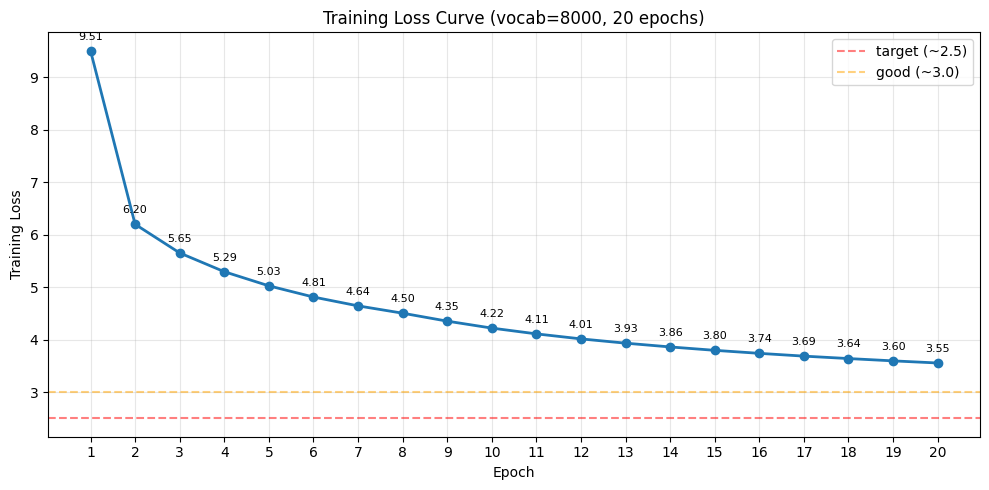

In [23]:
# 학습 결과 (Epoch 1~20 loss)
history = [
    9.5060, 6.1988, 5.6522, 5.2946, 5.0253,
    4.8119, 4.6435, 4.5039, 4.3523, 4.2199,
    4.1097, 4.0143, 3.9327, 3.8609, 3.7961,
    3.7387, 3.6857, 3.6394, 3.5954, 3.5548,
]

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(history)+1), history, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve (vocab=8000, 20 epochs)')
plt.grid(True, alpha=0.3)
plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='target (~2.5)')
plt.axhline(y=3.0, color='orange', linestyle='--', alpha=0.5, label='good (~3.0)')

# 각 점에 loss 값 표시
for i, v in enumerate(history, 1):
    plt.annotate(f'{v:.2f}', (i, v), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)

plt.legend()
plt.xticks(range(1, len(history)+1))
plt.tight_layout()
plt.show()

### 8-2 Cross-Attention 학습 전/후 비교 시각화 

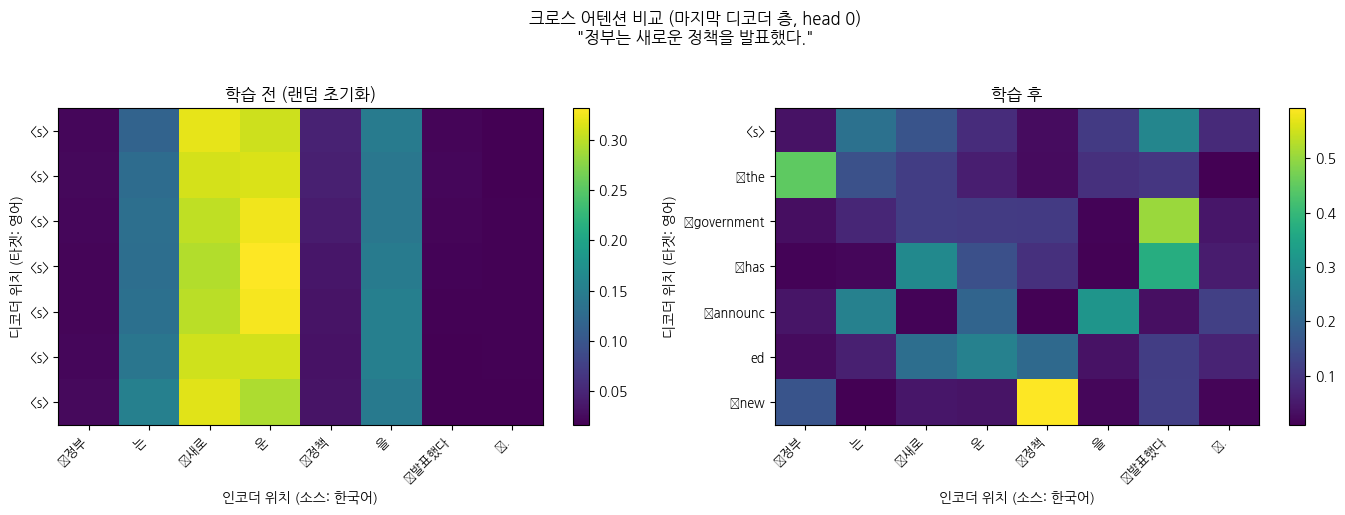

In [28]:
import matplotlib.pyplot as plt
import copy

# 한글 폰트
try:
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass


@torch.no_grad()
def get_cross_attention(model_to_use, sentence, head=0):
    """주어진 모델에서 마지막 디코더 레이어의 cross-attention(특정 head) 추출"""
    model_to_use.eval()
    
    # 입력 준비
    src_ids = kor_tokenizer.encode_as_ids(preprocess_sentence(sentence))
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    # 타겟은 BOS + 적당히 몇 토큰 (greedy로 생성)
    enc_mask = padding_mask(src)
    enc_out = model_to_use.encode(src, enc_mask)
    tgt = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    
    for _ in range(6):   # 6개 토큰만 생성해서 보기 좋게
        dec_mask = torch.max(padding_mask(tgt), causal_mask(tgt.shape[1]).to(device))
        dec_out = model_to_use.decode(tgt, enc_out, dec_mask, enc_mask)
        next_id = model_to_use.fc(dec_out[:, -1]).argmax(-1, keepdim=True)
        tgt = torch.cat([tgt, next_id], dim=1)
        if next_id.item() == EOS_ID:
            break
    
    # 디코더 마지막 레이어에서 cross-attention 캡처
    h = model_to_use._embed(model_to_use.dec_emb, tgt)
    dec_mask = torch.max(padding_mask(tgt), causal_mask(tgt.shape[1]).to(device))
    for layer in model_to_use.dec_layers[:-1]:
        h = layer(h, enc_out, dec_mask, enc_mask)
    last = model_to_use.dec_layers[-1]
    normed = last.norm1(h)
    sa, _ = last.self_attn(normed, normed, normed, dec_mask)
    h = h + last.dropout(sa)
    _, cross_attn = last.cross_attn(last.norm2(h), enc_out, enc_out, enc_mask)
    
    # (1, num_heads, T_tgt, T_src) → 지정 head만
    return cross_attn[0, head].cpu().numpy(), src_ids, tgt[0].tolist()


# 1) 학습 전 모델 (새로 random 초기화)
fresh_model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    max_len=POS_LEN, dropout=DROPOUT,
).to(device)

# 2) 학습 전/후 attention 추출
sentence = "정부는 새로운 정책을 발표했다."
attn_before, src_ids, tgt_ids_before = get_cross_attention(fresh_model, sentence, head=0)
attn_after,  _,       tgt_ids_after  = get_cross_attention(model, sentence, head=0)

# 3) 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attn, tgt_ids, title in [
    (axes[0], attn_before, tgt_ids_before, '학습 전 (랜덤 초기화)'),
    (axes[1], attn_after,  tgt_ids_after,  '학습 후'),
]:
    im = ax.imshow(attn, cmap='viridis', aspect='auto')
    
    # x축: 소스(한국어) 토큰
    src_tokens = [kor_tokenizer.id_to_piece(i) for i in src_ids]
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
    
    # y축: 타겟(영어) 토큰
    tgt_tokens = [eng_tokenizer.id_to_piece(i) for i in tgt_ids]
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=9)
    
    ax.set_xlabel('인코더 위치 (소스: 한국어)')
    ax.set_ylabel('디코더 위치 (타겟: 영어)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle(f'크로스 어텐션 비교 (마지막 디코더 층, head 0)\n"{sentence}"', y=1.02)
plt.tight_layout()
plt.show()

- 학습 전
    - 어텐션이 세로 줄무늬 형태 → 어떤 영어 토큰을 만들든 항상 같은 한국어 위치만 봄
- 학습 후
    - 생성된 영어: the government has announced new (정부는 새로운 정책을 발표했다)
    - 어텐션이 위치별로 다른 한국어 토큰에 집중.
- 언어간 어순차이로 완벽한 대각선 모양은 아니지만, 트랜스포머가 번역을 위한 단어 정렬을 실제로 학습했음을 시각적으로 증명.

## 9. 추론 (Greedy Decoding)
- 한 토큰씩 가장 확률 높은 걸 뽑아 가다가 `</s>` 나오면 종료.
- 인코더는 입력에 대해 한 번만 돌리고, 디코더만 토큰마다 반복 호출.

In [19]:
@torch.no_grad()  # 추론 중에는 gradient 계산 불필요 (메모리/속도 절약)
def translate(sentence, max_len=MAX_LEN):
    """
    한국어 문장 한 개를 영어로 번역.
    
    절차:
      1) 입력 전처리 + 토큰화
      2) 인코더 1회 실행 → enc_out 캐싱
      3) BOS부터 시작해 max_len까지 한 토큰씩 디코더로 다음 토큰 예측
      4) EOS가 나오면 즉시 종료
      5) 토큰 ID들을 문자열로 디코딩
    """
    model.eval()  # 평가 모드 (Dropout 끔)

    # 1) 입력 전처리 → 토큰 ID → 배치 차원 추가 (B=1)
    src_ids = kor_tokenizer.encode_as_ids(preprocess_sentence(sentence))
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    # 2) 인코더 한 번만 실행 (입력은 변하지 않으므로 재활용)
    enc_mask = padding_mask(src)
    enc_out = model.encode(src, enc_mask)

    # 3) 디코더 입력 초기값: [[BOS]]
    tgt = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    # 4) 토큰을 하나씩 생성
    for _ in range(max_len):
        # 디코더 셀프 마스크 (현재까지 길이에 맞춰 매번 새로 만듦)
        dec_mask = torch.max(
            padding_mask(tgt),
            causal_mask(tgt.shape[1]).to(device)
        )
        # 디코더 forward
        dec_out = model.decode(tgt, enc_out, dec_mask, enc_mask)
        # 마지막 위치의 logit만 사용 → argmax로 가장 확률 높은 토큰 선택
        next_id = model.fc(dec_out[:, -1]).argmax(-1, keepdim=True)
        # tgt 뒤에 붙여서 다음 step 입력으로
        tgt = torch.cat([tgt, next_id], dim=1)
        # EOS면 종료
        if next_id.item() == EOS_ID:
            break

    # 5) BOS 제외하고, EOS 이전까지만 잘라 디코딩
    out_ids = tgt[0, 1:].tolist()
    if EOS_ID in out_ids:
        out_ids = out_ids[:out_ids.index(EOS_ID)]
    return eng_tokenizer.decode_ids(out_ids)


# 사용 예
# print(translate('오늘 날씨가 정말 좋네요.'))
# print(translate('그는 어제 새로운 책을 샀습니다.'))

- 번역 결과

In [20]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")

 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: they re on the mountain .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s a coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the saturday attack .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was thrown yesterday .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: korea is the country is beautiful .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has announced new policy .
----------------------------------------------------------------------
 8. KO: 경제는 빠르게 성장하고 있다.
    EN: econ

## 10. 회고
```
Transformer를 이용한 한영 번역기를 만들었다.
몇개 문장이 정상적이진 않지만, 한국어와 영어를 단어 단위로 서로 매칭하는 법을 스스로 학습했다.
그 결과 이전 seq2seq 보다는 번역 결과가 잘 나왔다.
학습시간도 Attention만 이용한 알고리즘이라 일괄 병렬처리로 더 빠르게 진행되었다.
노드 소스의 혼선으로 정상 소스 찾아가는 데 시간이 많이 걸렸다.
Transformer활용을 위해서는 소스 구조에 대한 좀더 깊은 이해는 필요해 보인다.
무엇을 변경해야 좀더 나은 번역 결과가 나오는지, vocab_size는 어느정도가 적당한지,
echoch은 몇회가 적절한지 등등 적절한 하이퍼파라메터 값을 적용하려면 많은 실습이 필요할 것 같다. 
```
